## 1. 导入和配置


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from stats_utils import *
setup_plotting()
OUTPUT_PATH = BASE_PATH / "reports" / "comparison" / "frequency_channel"
OUTPUT_PATH, FIGURES_PATH = ensure_output_dirs(OUTPUT_PATH)
print(f"输出目录: {OUTPUT_PATH}")
print(f"图片目录: {FIGURES_PATH}")


输出目录: d:\LYW\REST_COM\reports\comparison\frequency_channel
图片目录: d:\LYW\REST_COM\reports\comparison\frequency_channel\figures


## 2. Channel-level 数据加载


In [2]:
import mne
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

BANDS = {"Delta": (0.5, 4), "Theta": (4, 8), "Alpha": (8, 13), "Beta": (13, 30), "Gamma": (30, 45)}
EPOCH_DATA_PATH = BASE_PATH / "preprocessing" / "data" / "6epoch_clean"

SUBJECT_GROUPS = {}
for group in GROUPS:
    group_path = EPOCH_DATA_PATH / group
    if group_path.exists():
        SUBJECT_GROUPS[group] = [f.stem.replace("-epo", "") for f in group_path.glob("*-epo.fif")]

def load_channel_trial_data():
    all_trials = []
    for group in GROUPS:
        print(f"加载 {GROUP_LABELS[group]}...")
        for subject_id in SUBJECT_GROUPS[group]:
            epoch_file = EPOCH_DATA_PATH / group / f"{subject_id}-epo.fif"
            if not epoch_file.exists():
                continue
            epochs = mne.read_epochs(epoch_file, preload=True, verbose=False)
            psd = epochs.compute_psd(method="welch", fmin=0.5, fmax=45, verbose=False)
            psds, freqs = psd.get_data(return_freqs=True)
            for trial_idx in range(len(epochs)):
                for ch_idx in range(psds.shape[1]):
                    ch_name = epochs.ch_names[ch_idx]
                    for band_name, (fmin, fmax) in BANDS.items():
                        freq_mask = (freqs >= fmin) & (freqs < fmax)
                        power = psds[trial_idx, ch_idx, freq_mask].mean()
                        all_trials.append({
                            "subject_id": subject_id, "group": group, "trial_idx": trial_idx,
                            "channel": ch_name, "band": band_name, "power": power,
                            "log_power": np.log10(power + 1e-20)
                        })
            print(f"  {subject_id}: {len(epochs)} trials")
    return pd.DataFrame(all_trials)

trial_df_channel = load_channel_trial_data()
print()
print(f"总数据点: {len(trial_df_channel)}")
print(f"被试数: {trial_df_channel['subject_id'].nunique()}")
print(f"通道数: {trial_df_channel['channel'].nunique()}")
print(f"频段数: {trial_df_channel['band'].nunique()}")
print()
print("数据预览:")
trial_df_channel.head(10)

加载 ADHD单纯组...
  018: 19 trials
  029: 22 trials
  031: 19 trials
  037: 25 trials
  038: 30 trials
  045: 19 trials
  075: 26 trials
  091: 23 trials
  094: 30 trials
  117: 28 trials
  132: 17 trials
  134: 19 trials
加载 ADHD共患阅读困难组...
  001: 24 trials
  020: 22 trials
  021: 24 trials
  022: 18 trials
  024: 22 trials
  047: 19 trials
  049: 20 trials
  051: 27 trials
  072: 27 trials
  073: 26 trials
  076: 17 trials
  092: 15 trials
  113: 29 trials
  150: 21 trials
加载 正常发展组...
  006: 23 trials
  068: 23 trials
  079: 28 trials
  093: 26 trials
  108: 23 trials
  109: 19 trials
  127: 17 trials
  133: 24 trials

总数据点: 227445
被试数: 34
通道数: 60
频段数: 5

数据预览:


,subject_id,group,trial_idx,channel,band,power,log_power
0,018,adhd,0,Fp1,Delta,1.277998e-11,-10.893470
1,018,adhd,0,Fp1,Theta,2.430278e-12,-11.614344
2,018,adhd,0,Fp1,Alpha,3.908534e-12,-11.407986
3,018,adhd,0,Fp1,Beta,2.983796e-13,-12.525231
4,018,adhd,0,Fp1,Gamma,9.251113e-14,-13.033806
5,018,adhd,0,F3,Delta,2.198658e-11,-10.657842
6,018,adhd,0,F3,Theta,2.139873e-12,-11.669612
7,018,adhd,0,F3,Alpha,2.265785e-12,-11.644781
8,018,adhd,0,F3,Beta,1.940740e-13,-12.712033
9,018,adhd,0,F3,Gamma,3.792388e-14,-13.421087


## 3. Channel-level LME 分析


In [3]:
import statsmodels.formula.api as smf

lme_results_channel = {}
channel_summary = []
channels = sorted(trial_df_channel['channel'].unique())
total_tests = len(channels) * len(BANDS)

print(f"开始分析 {len(channels)} 个通道 × {len(BANDS)} 个频段 = {total_tests} 次检验")
print("=" * 70)

for i, channel in enumerate(channels, 1):
    print()
    print(f"[{i}/{len(channels)}] {channel}")
    lme_results_channel[channel] = {}
    for band in BANDS.keys():
        ch_band_df = trial_df_channel[
            (trial_df_channel['channel'] == channel) & 
            (trial_df_channel['band'] == band)
        ].copy()
        model = smf.mixedlm(
            "log_power ~ C(group, Treatment('td'))",
            data=ch_band_df,
            groups=ch_band_df["subject_id"],
            re_formula="~1"
        )
        result = model.fit(method="lbfgs")
        lme_results_channel[channel][band] = result
        for param in result.fe_params.index:
            if "group" in param and "Intercept" not in param:
                beta = result.fe_params[param]
                p = result.pvalues[param]
                group_name = "ADHD" if "adhd" in param.lower() else "COM"
                channel_summary.append({
                    "channel": channel, "band": band,
                    "comparison": f"{group_name} vs TD",
                    "beta": beta, "p": p
                })

channel_summary_df = pd.DataFrame(channel_summary)
print()
print()
print(f"总检验数: {len(channel_summary_df)}")


开始分析 60 个通道 × 5 个频段 = 300 次检验

[1/60] AF3

[2/60] AF4

[3/60] AF7

[4/60] AFz

[5/60] C1

[6/60] C2

[7/60] C3

[8/60] C4

[9/60] C5

[10/60] C6

[11/60] CP1

[12/60] CP2

[13/60] CP3

[14/60] CP4

[15/60] CP5

[16/60] CP6

[17/60] CPz

[18/60] Cz

[19/60] F1

[20/60] F2

[21/60] F3

[22/60] F4

[23/60] F5

[24/60] F6

[25/60] F7

[26/60] F8

[27/60] F9

[28/60] FC1

[29/60] FC2

[30/60] FC3

[31/60] FC4

[32/60] FC5

[33/60] FC6

[34/60] FCz

[35/60] FT7

[36/60] FT8

[37/60] Fp1

[38/60] Fp2

[39/60] Fz

[40/60] O1

[41/60] O2

[42/60] Oz

[43/60] P1

[44/60] P2

[45/60] P3

[46/60] P4

[47/60] P5

[48/60] P6

[49/60] P7

[50/60] P8

[51/60] PO3

[52/60] PO4

[53/60] PO7

[54/60] PO8

[55/60] POz

[56/60] Pz

[57/60] T7

[58/60] T8

[59/60] TP7

[60/60] TP8


总检验数: 600


## 4. FDR 校正


In [4]:
from statsmodels.stats.multitest import multipletests

channel_summary_df["p_fdr"] = multipletests(channel_summary_df["p"], method="fdr_bh")[1]
channel_summary_df['significant'] = channel_summary_df["p_fdr"] < 0.05

print("FDR校正后显著结果:")
sig_results = channel_summary_df[channel_summary_df['significant']]
if len(sig_results) > 0:
    print(sig_results[["channel", "band", "comparison", "beta", "p", "p_fdr"]].to_string(index=False))
else:
    print("  无显著结果")

print()
print(f"显著结果数: {len(sig_results)}/{len(channel_summary_df)}")

channel_summary_df.to_csv(OUTPUT_PATH / "channel_lme_results.csv", index=False, encoding="utf-8-sig")
print()
print("✓ Channel LME结果已保存")


FDR校正后显著结果:
  无显著结果

显著结果数: 0/600

✓ Channel LME结果已保存


## 5. 地形图可视化


In [5]:
import matplotlib.pyplot as plt

sample_file = list((EPOCH_DATA_PATH / "adhd").glob("*-epo.fif"))[0]
sample_epochs = mne.read_epochs(sample_file, preload=False, verbose=False)
info = sample_epochs.info

# 只保留数据中实际存在的通道
data_channels = sorted(trial_df_channel['channel'].unique())
picks = mne.pick_channels(info['ch_names'], include=data_channels, ordered=False)
info = mne.pick_info(info, picks)
print(f"通道信息: {len(info['ch_names'])} 个通道")
print(f"数据通道: {len(data_channels)} 个通道")

通道信息: 59 个通道
数据通道: 60 个通道


ValueError: Number of channels in the Info object (58) and the data array (59) do not match.Pick Info with e.g. mne.pick_info and mne.channel_indices_by_type.

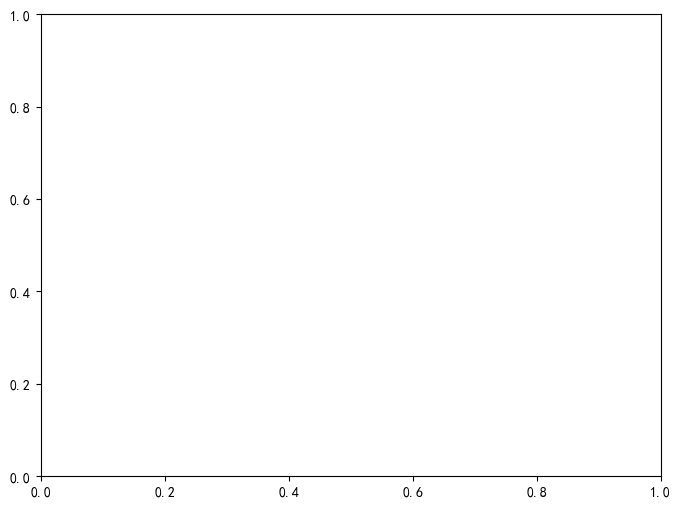

In [6]:
def plot_topomap_pvalues(summary_df, comparison, band, info, save_path):
    subset = summary_df[(summary_df['comparison'] == comparison) & (summary_df['band'] == band)]
    ch_pvalues = {}
    for _, row in subset.iterrows():
        ch_pvalues[row['channel']] = row['p_fdr']
    # 只使用 info 中存在的通道，确保数组长度匹配
    info_ch_names = info['ch_names']
    pvalues = [ch_pvalues.get(ch, 1.0) for ch in info_ch_names]
    log_pvalues = np.array([-np.log10(p) if p > 0 else 10 for p in pvalues])
    fig, ax = plt.subplots(figsize=(8, 6))
    im, _ = mne.viz.plot_topomap(log_pvalues, info, axes=ax, show=False,
                                  cmap='hot', vlim=(0, 3))
    ax.set_title(f"{comparison} - {band}\n-log10(p_fdr)")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

for comparison in ["ADHD vs TD", "COM vs TD"]:
    for band in BANDS.keys():
        filename = f"topomap_{comparison.replace(' ', '_')}_{band}.png"
        plot_topomap_pvalues(channel_summary_df, comparison, band, info, FIGURES_PATH / filename)

print("✓ 地形图已保存")

## 6. 综合报告


In [ ]:
print("=" * 70)
print("Channel-level 分析结果总结")
print("=" * 70)
print()
print(f"总检验数: {len(channel_summary_df)}")
print(f"显著结果数 (FDR < 0.05): {len(sig_results)}")

if len(sig_results) > 0:
    print()
    print("显著发现:")
    for _, row in sig_results.iterrows():
        direction = "增加" if row['beta'] > 0 else "降低"
        print(f"  - {row['channel']} {row['band']}: {row['comparison']} {direction} (β={row['beta']:.4f}, p_fdr={row['p_fdr']:.4f})")
    print()
    print("按频段汇总:")
    for band in BANDS.keys():
        band_sig = sig_results[sig_results['band'] == band]
        print(f"  {band}: {len(band_sig)} 个显著通道")
    print()
    print("按比较汇总:")
    for comp in ["ADHD vs TD", "COM vs TD"]:
        comp_sig = sig_results[sig_results['comparison'] == comp]
        print(f"  {comp}: {len(comp_sig)} 个显著结果")
else:
    print()
    print("未发现显著的通道特异性组间差异")

print()
print("分析完成！")
